# Xelians Export

Exploratory Data Analysis

### Xelians files

In [42]:
import pandas as pd

df_files = pd.read_csv("xelians-filenames.csv", sep="_")
df_files.head()

,idContract,idCourier,codeTypology,xeliansFilename
0,039571-a2d99e05-3023-ea11-a2d5-0050569c0763,357c1839-1449-4f40-976e-b886e4c4ba26,C049,pdf
1,039571-a2d99e05-3023-ea11-a2d5-0050569c0763,357c1839-1449-4f40-976e-b886e4c4ba26,C051,pdf
2,039571-a2d99e05-3023-ea11-a2d5-0050569c0763,357c1839-1449-4f40-976e-b886e4c4ba26,C076,pdf
3,039571-a2d99e05-3023-ea11-a2d5-0050569c0763,357c1839-1449-4f40-976e-b886e4c4ba26,C105,pdf
4,039571-a2d99e05-3023-ea11-a2d5-0050569c0763,357c1839-1449-4f40-976e-b886e4c4ba26,C107,pdf


In [43]:
df_files.info()

<class 'pandas.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   idContract       1043 non-null   str  
 1   idCourier        1043 non-null   str  
 2   codeTypology     1043 non-null   str  
 3   xeliansFilename  1043 non-null   str  
dtypes: str(4)
memory usage: 32.7 KB


In [44]:
df_files.drop_duplicates().count()

idContract         1043
idCourier          1043
codeTypology       1043
xeliansFilename    1043
dtype: int64

In [45]:
df_files.describe()

,idContract,idCourier,codeTypology,xeliansFilename
count,1043,1043,1043,1043
unique,113,135,61,3
top,121772-c88a5746-d988-f011-b4cc-6045bda1ae8e,b01ae5ae-ac3d-4bb1-b818-e4c41c00e9b5,C069,pdf
freq,40,19,102,997


In [46]:
df_files.groupby("idContract").count()

,idCourier,codeTypology,xeliansFilename
idContract,,,
039571-a2d99e05-3023-ea11-a2d5-0050569c0763,5,5,5
105595-48fcaaca-4e0f-ef11-9f89-6045bd9909e7,11,11,11
110025-16f5ae47-2ca7-ef11-b8e8-7c1e525e9311,6,6,6
111279-128e2e94-66cf-ef11-b8e8-6045bd930ece,9,9,9
111469-65644199-bfd4-ef11-8eea-000d3aac506b,5,5,5
...,...,...,...
124878-011cc928-c0c3-f011-bbd3-6045bd8f8f87,7,7,7
125145-61fc4c87-26c6-f011-bbd3-7ced8d0f70f6,6,6,6
125856-7ae60381-852c-ef11-840a-000d3a499c98,7,7,7


In [47]:
df_files.groupby("codeTypology").count()

,idContract,idCourier,xeliansFilename
codeTypology,,,
20,13,13,13
A003,1,1,1
C003,82,82,82
C004,101,101,101
C005,3,3,3
...,...,...,...
C901,4,4,4
C906,3,3,3
C907,1,1,1


### Xelians codes

In [48]:
df_codes = pd.read_csv("Xelians-DocumentType.csv", sep=",")
df_codes.head()

,XeliansCode,Description,FrenchLabel,EnglishLabel
0,A001,Dossier de souscription Arkéa (PP),Dossier de souscription Arkéa (PP),Arkea subscription form (Individual)
1,A002,Dossier de souscription Arkéa (2PP),Dossier de souscription Arkéa (2PP),Arkea subscription form (Two individual)
2,A003,Dossier de souscription Arkéa (PM),Dossier de souscription Arkéa (PM),Arkea subscription form (Legal entity)
3,C001,BS CC - Souscription,CORUM Origin - Bulletin de souscription,CORUM Origin - Subscription Form
4,C002,TITRE DE PROPRIETE,Titre de propriété,Title of ownership


In [49]:
df_codes.describe()

,XeliansCode,Description,FrenchLabel,EnglishLabel
count,234,234,234,234
unique,234,215,170,170
top,A001,CORUM XL - Bulletin de souscription,Document lié au financement par Corum,Document related to financing by Corum
freq,1,4,19,19


### Merged dataframes

In [50]:
code_to_label = df_codes.set_index("XeliansCode")["FrenchLabel"]
df_files["codeTypology"] = df_files["codeTypology"].map(code_to_label)

In [51]:
df_files['codeTypology'].describe()

count                           1043
unique                            50
top       Documents d'audit/contrôle
freq                             102
Name: codeTypology, dtype: object

## Some Statistics

In [52]:
print(f"Contrats         : {df_files['idContract'].nunique()}")
print(f"Documents total  : {len(df_files)}")
print(f"Moy. docs/contrat: {len(df_files)/df_files['idContract'].nunique():.1f}")
print(f"Typologies uniques: {df_files['codeTypology'].nunique()}")
print(f"Formats présents : {df_files['xeliansFilename'].unique()}")

Contrats         : 113
Documents total  : 1043
Moy. docs/contrat: 9.2
Typologies uniques: 50
Formats présents : <StringArray>
['pdf', 'jpg', 'png']
Length: 3, dtype: str


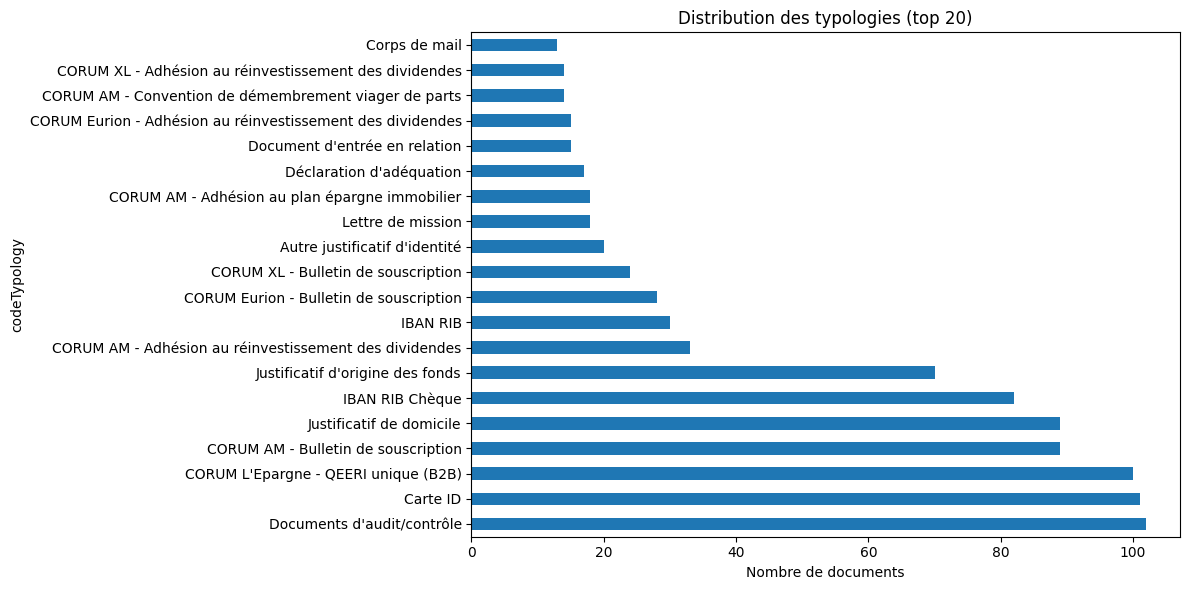

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution des typologies (top 20)
top = df_files["codeTypology"].value_counts().head(20)

plt.figure(figsize=(12, 6))
top.plot(kind="barh")
plt.title("Distribution des typologies (top 20)")
plt.xlabel("Nombre de documents")
plt.tight_layout()
plt.show()

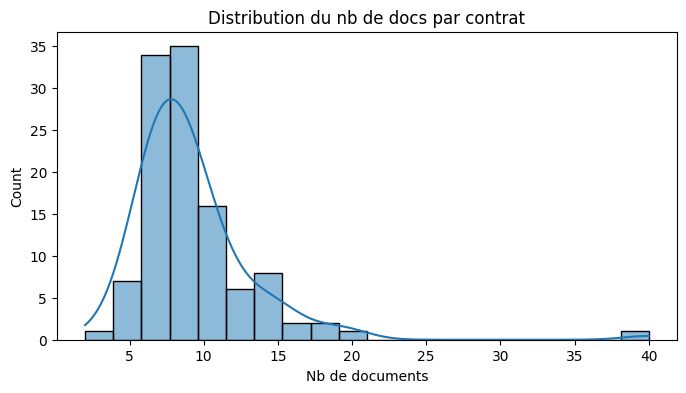

In [54]:
# Nombre de documents par contrat (histogramme)
docs_per_contract = df_files.groupby("idContract").size()

plt.figure(figsize=(8, 4))
sns.histplot(docs_per_contract, bins=20, kde=True)
plt.title("Distribution du nb de docs par contrat")
plt.xlabel("Nb de documents")
plt.show()

In [55]:
# Avec plotly pour interactivité
import plotly.express as px

fig = px.bar(
    top.reset_index(),
    x="count", y="codeTypology",
    orientation="h",
    title="Distribution des typologies"
)
fig.show()

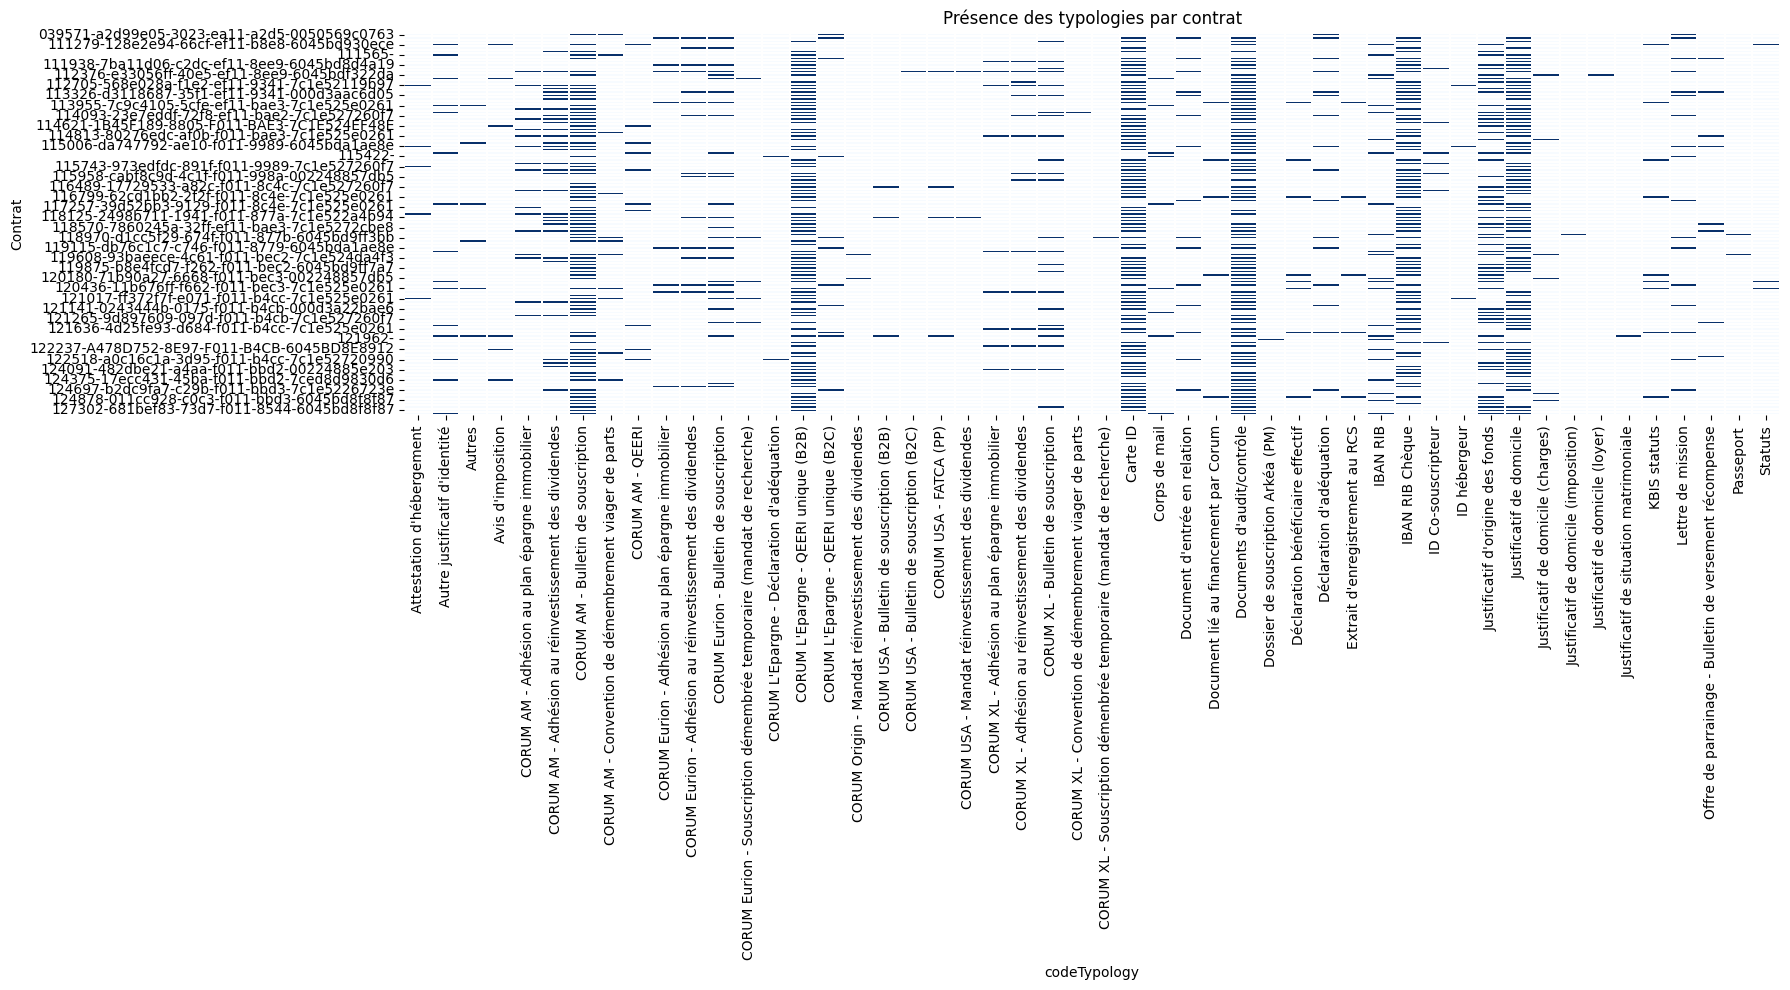

In [56]:
# Pivot : contrat × typologie → 1 si présent
pivot = df_files.groupby(["idContract", "codeTypology"]).size().unstack(fill_value=0).clip(upper=1)

plt.figure(figsize=(18, 10))
sns.heatmap(pivot, cmap="Blues", cbar=False, linewidths=0.1)
plt.title("Présence des typologies par contrat")
plt.ylabel("Contrat")
plt.tight_layout()

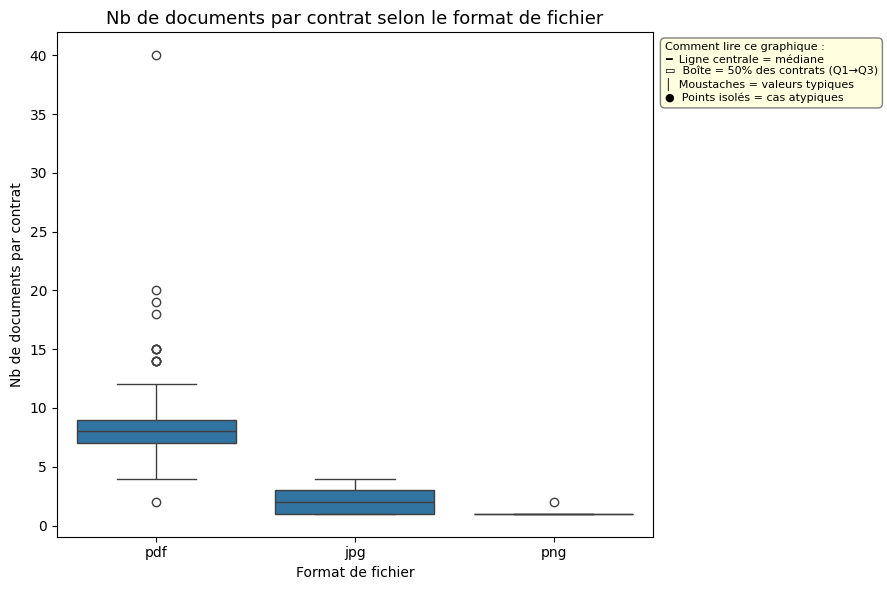

In [57]:
docs_per_contract = df_files.groupby(["idContract", "xeliansFilename"]).size().reset_index(name="count")
plt.style.use("default")  # force le fond blanc

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")   # fond de la figure
ax.set_facecolor("white")          # fond du graphique

sns.boxplot(data=docs_per_contract, x="xeliansFilename", y="count", ax=ax)

ax.set_title("Nb de documents par contrat selon le format de fichier", fontsize=13, color="black")
ax.set_xlabel("Format de fichier", color="black")
ax.set_ylabel("Nb de documents par contrat", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend_text = (
    "Comment lire ce graphique :\n"
    "━  Ligne centrale = médiane\n"
    "▭  Boîte = 50% des contrats (Q1→Q3)\n"
    "│  Moustaches = valeurs typiques\n"
    "●  Points isolés = cas atypiques"
)
ax.text(
    1.02, 0.98, legend_text,
    transform=ax.transAxes,
    fontsize=8, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", edgecolor="gray")
)

plt.tight_layout()
plt.show()

In [58]:
import plotly.express as px

counts = df_files["codeTypology"].value_counts().reset_index()
counts.columns = ["codeTypology", "count"]

fig = px.treemap(counts, path=["codeTypology"], values="count",
                 title="Répartition des typologies")
fig.show()

In [59]:
stats = df_files.groupby("idContract").agg(
    total_docs=("codeTypology", "count"),
    unique_types=("codeTypology", "nunique")
).reset_index()

fig = px.scatter(stats, x="total_docs", y="unique_types",
                 hover_data=["idContract"],
                 title="Complexité des dossiers (docs vs types uniques)",
                 labels={"total_docs": "Nb de documents", "unique_types": "Nb de typologies uniques"})
fig.show()

Text(0.5, 1.0, 'Typologies les plus fréquentes (présence dans les dossiers)')

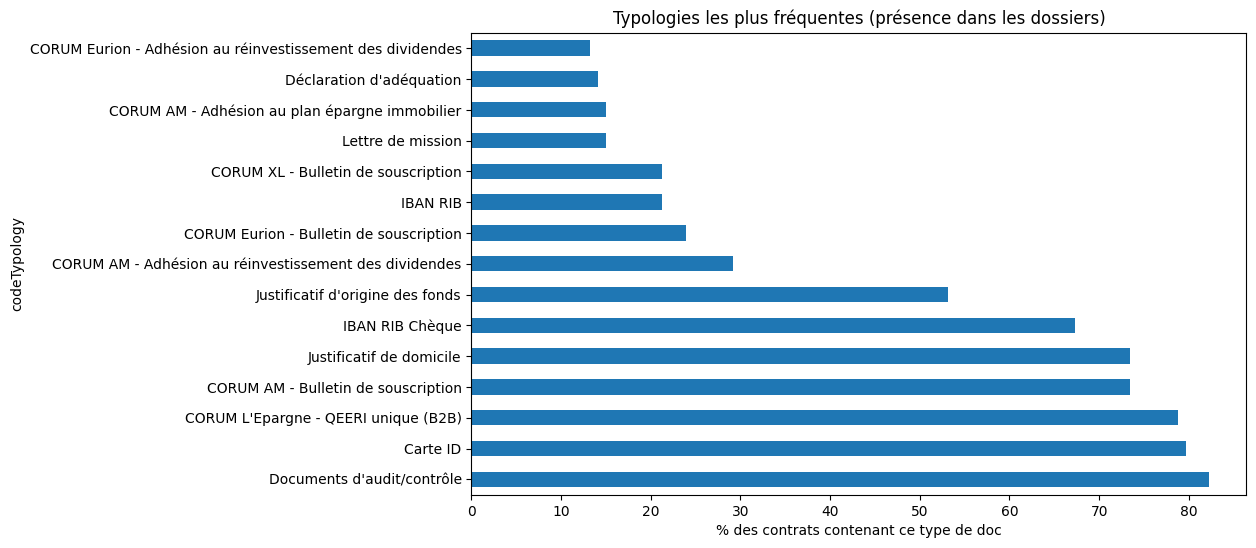

In [60]:
# Quelles typologies sont "obligatoires" ? (présentes dans >X% des contrats)
n_contracts = df_files["idContract"].nunique()
presence_rate = (
    df_files.groupby("codeTypology")["idContract"].nunique() / n_contracts * 100
).sort_values(ascending=False)

presence_rate.head(15).plot(kind="barh", figsize=(10, 6))
plt.xlabel("% des contrats contenant ce type de doc")
plt.title("Typologies les plus fréquentes (présence dans les dossiers)")

76 cas de doublons sur 19 contrats


Text(0.5, 1.0, 'Types de docs les plus souvent en doublon')

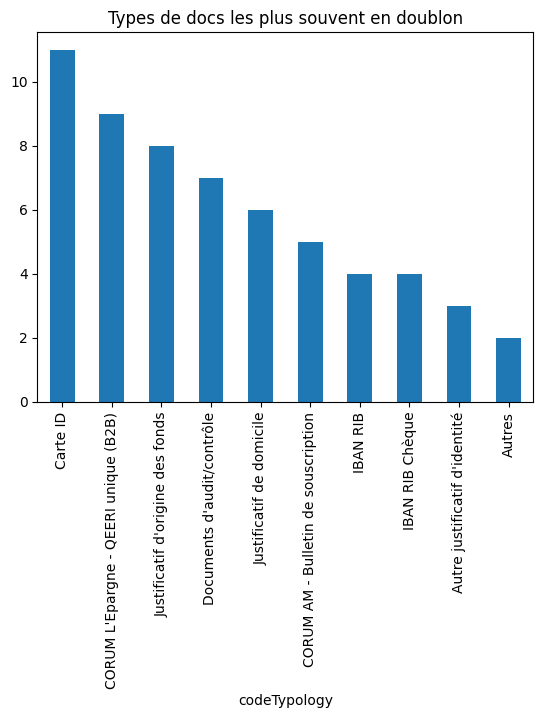

In [61]:
# Contrats avec plusieurs docs du même type (doublons potentiels)
dupes = df_files.groupby(["idContract", "codeTypology"]).size()
dupes = dupes[dupes > 1].reset_index(name="count")
print(f"{len(dupes)} cas de doublons sur {dupes['idContract'].nunique()} contrats")
dupes["codeTypology"].value_counts().head(10).plot(kind="bar")
plt.title("Types de docs les plus souvent en doublon")

### Clustering des dossiers par composition documentaire

Ce graphique regroupe les contrats en **profils types** selon les documents qu'ils contiennent,
en utilisant un algorithme de clustering (K-Means).

Chaque **cluster** représente un groupe de contrats ayant une composition documentaire similaire :
les contrats d'un même cluster tendent à contenir les mêmes typologies de documents.

**Comment interpréter les groupes ?**
- Un cluster de grande taille = un profil de dossier très répandu
- Un cluster de petite taille = des dossiers atypiques ou plus complexes
- En inspectant les typologies dominantes de chaque cluster, on peut qualifier chaque profil
  (ex : *"dossier standard"*, *"dossier avec pièces complémentaires"*, *"dossier incomplet"*)

> ⚙️ *Le nombre de clusters (ici 10) est un paramètre à ajuster selon la granularité souhaitée.*

Text(0.5, 1.0, 'Répartition des contrats par profil type')

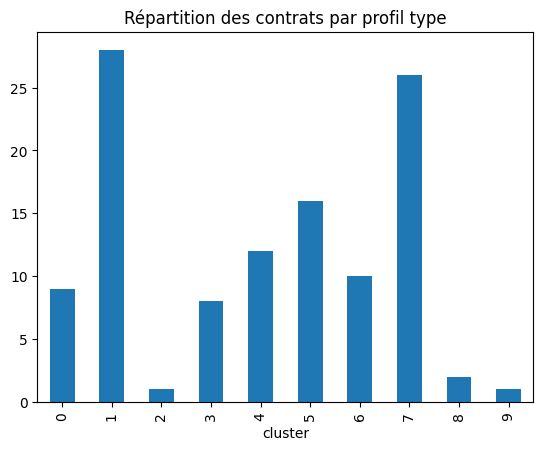

In [74]:
#CLustering des contrats : similitude de composition
from sklearn.cluster import KMeans

pivot = df_files.groupby(["idContract", "codeTypology"]).size().unstack(fill_value=0)
kmeans = KMeans(n_clusters=10, random_state=42).fit(pivot)
pivot["cluster"] = kmeans.labels_

pivot["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Répartition des contrats par profil type")

In [64]:
pivot["cluster"] = kmeans.labels_
pivot_reset = pivot.drop(columns=["cluster"]).copy()
pivot_reset["cluster"] = kmeans.labels_

# Top 3 typologies par cluster
for c in sorted(pivot_reset["cluster"].unique()):
    top3 = pivot_reset[pivot_reset["cluster"] == c].drop(columns="cluster").mean().nlargest(3)
    print(f"\nCluster {c} ({(pivot_reset['cluster']==c).sum()} contrats)")
    print(top3.to_string())


Cluster 0 (9 contrats)
codeTypology
CORUM Eurion - Adhésion au réinvestissement des dividendes    1.0
CORUM Eurion - Bulletin de souscription                       1.0
Carte ID                                                      1.0

Cluster 1 (28 contrats)
codeTypology
Carte ID                               1.107143
CORUM AM - Bulletin de souscription    1.000000
IBAN RIB Chèque                        1.000000

Cluster 2 (1 contrats)
codeTypology
Autre justificatif d'identité           4.0
Avis d'imposition                       4.0
CORUM L'Epargne - QEERI unique (B2B)    4.0

Cluster 3 (8 contrats)
codeTypology
CORUM L'Epargne - QEERI unique (B2B)    1.375
Documents d'audit/contrôle              1.375
IBAN RIB                                1.375

Cluster 4 (12 contrats)
codeTypology
CORUM AM - Bulletin de souscription    1.083333
Carte ID                               1.083333
Déclaration d'adéquation               1.083333

Cluster 5 (16 contrats)
codeTypology
IBAN RIB           